In [1]:
import numpy as np
from scipy import stats
import scipy
import matplotlib.pyplot as plt
import pandas as pd

## 1

### assumptions: residuals are independent and random or the tests are fully randomized

In [70]:
strength_Q1 = np.array([89,88,97,94,84,77,92,79,81,87,87,85,87,92,89,84,79,81,80,88])

In [29]:
df1 = pd.DataFrame({
    'raw_mat': np.repeat(np.arange(5)+1, 4),
    'operator': np.tile([i for i in 'ABCD'],5),
    'strength': (strength_Q1),
})

In [30]:
df1['grand_ave'] = df1['strength'].mean()
df1['raw_mat_ave'] = df1.groupby('raw_mat')['strength'].transform('mean')
df1['operator_ave'] = df1.groupby('operator')['strength'].transform('mean')

In [31]:
df1['raw_mat_dev'] = df1['raw_mat_ave'] - df1['grand_ave']
df1['operator_dev'] = df1['operator_ave'] - df1['grand_ave']

In [32]:
df1['predicted_strength'] =  df1['grand_ave'] + df1['raw_mat_dev'] + df1['operator_dev']

In [33]:
df1['residual'] = df1['strength'] - df1['grand_ave'] - df1['raw_mat_dev'] - df1['operator_dev']

In [34]:
df1

,raw_mat,operator,strength,grand_ave,raw_mat_ave,operator_ave,raw_mat_dev,operator_dev,predicted_strength,residual
0,1,A,89,86.0,92.0,84.0,6.0,-2.0,90.0,-1.0
1,1,B,88,86.0,92.0,85.0,6.0,-1.0,91.0,-3.0
2,1,C,97,86.0,92.0,89.0,6.0,3.0,95.0,2.0
3,1,D,94,86.0,92.0,86.0,6.0,0.0,92.0,2.0
4,2,A,84,86.0,83.0,84.0,-3.0,-2.0,81.0,3.0
5,2,B,77,86.0,83.0,85.0,-3.0,-1.0,82.0,-5.0
6,2,C,92,86.0,83.0,89.0,-3.0,3.0,86.0,6.0
7,2,D,79,86.0,83.0,86.0,-3.0,0.0,83.0,-4.0
8,3,A,81,86.0,85.0,84.0,-1.0,-2.0,83.0,-2.0
9,3,B,87,86.0,85.0,85.0,-1.0,-1.0,84.0,3.0


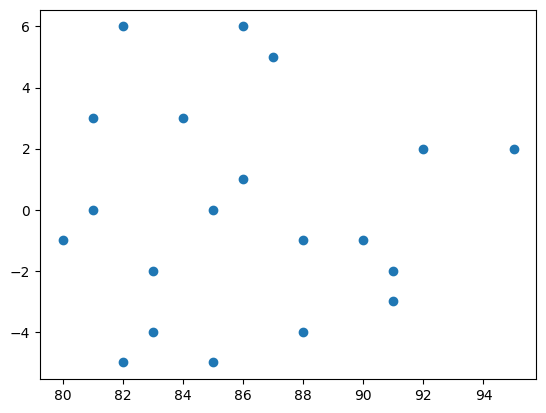

In [35]:
plt.scatter(df1['predicted_strength'], df1['residual'])

In [36]:
df1_ANOVA = (df1[['raw_mat_dev', 'operator_dev', 'residual']]**2).sum().to_frame(name='sum_squares') # sum of squares

In [37]:
df1_ANOVA['dof'] = [4,3,12]
df1_ANOVA['mean_square'] = df1_ANOVA['sum_squares'] / df1_ANOVA['dof']

In [38]:
df1_ANOVA['ratio_mean_square'] = df1_ANOVA['mean_square'] / df1_ANOVA.loc['residual', 'mean_square'] 

In [42]:
stats.f.sf(df1_ANOVA.loc['operator_dev', 'ratio_mean_square'], dfn=3, dfd=12) # no significant difference btw operators

np.float64(0.33865811618671526)

In [40]:
# test transformable nonadditivity
df1['q'] = df1['predicted_strength']**2
df1['q_ave'] = df1['q'].mean()
df1['q_raw_mat_dev'] = df1.groupby('raw_mat')['q'].transform('mean') - df1['q_ave']
df1['q_operator_dev'] = df1.groupby('operator')['q'].transform('mean') - df1['q_ave']
df1['predicted_q'] = df1['q_ave'] + df1['q_raw_mat_dev'] + df1['q_operator_dev']

In [41]:
P_Q1 = ((df1['strength'] - df1['predicted_strength']) * (df1['q'] - df1['predicted_q'])).sum()
Q_Q1 =((df1['q'] - df1['predicted_q'])**2).sum()
Sna_Q1 = P_Q1**2/Q_Q1
Sna_Q1 # degrees of freedom: 1

np.float64(2.0010822510822512)

In [44]:
df1_NonAdd_ANOVA = pd.DataFrame({
    'sum_squares': [df1_ANOVA.loc['residual', 'sum_squares'], Sna_Q1],
    'dof':  [df1_ANOVA.loc['residual', 'dof'] - 1, 1],
}, index=['residual', 'NonAdd_trans'])
df1_NonAdd_ANOVA

,sum_squares,dof
residual,226.000000,11
NonAdd_trans,2.001082,1


In [45]:
df1_NonAdd_ANOVA['mean_square'] = df1_NonAdd_ANOVA['sum_squares'] / df1_NonAdd_ANOVA['dof']
df1_NonAdd_ANOVA['ratio_mean_square'] = df1_NonAdd_ANOVA['mean_square'] / df1_NonAdd_ANOVA.loc['residual', 'mean_square']

In [47]:
stats.f.sf(df1_NonAdd_ANOVA.loc['NonAdd_trans', 'ratio_mean_square'], dfn=1, dfd=11) # no significant difference meaning no nonadditive transformations

np.float64(0.7608109850395327)

### Problem 1, 2, 3, and 4 require the same process. Define a function and call it for each problem

In [90]:
def q1_anova(df):
    df['grand_ave'] = df['strength'].mean()
    df['raw_mat_ave'] = df.groupby('raw_mat')['strength'].transform('mean')
    df['operator_ave'] = df.groupby('operator')['strength'].transform('mean')
    df['raw_mat_dev'] = df['raw_mat_ave'] - df['grand_ave']
    df['operator_dev'] = df['operator_ave'] - df['grand_ave']  
    df['predicted_strength'] =  df['grand_ave'] + df['raw_mat_dev'] + df['operator_dev']
    df['residual'] = df['strength'] - df['grand_ave'] - df['raw_mat_dev'] - df['operator_dev']

    # plot residuals
    plt.scatter(df['predicted_strength'], df['residual'])  

    df_ANOVA = (df[['raw_mat_dev', 'operator_dev', 'residual']]**2).sum().to_frame(name='sum_squares') # sum of squares
    df_ANOVA['dof'] = [4,3,12]
    df_ANOVA['mean_square'] = df_ANOVA['sum_squares'] / df_ANOVA['dof']
    df_ANOVA['ratio_mean_square'] = df_ANOVA['mean_square'] / df_ANOVA.loc['residual', 'mean_square'] 
    operator_f = stats.f.sf(df_ANOVA.loc['operator_dev', 'ratio_mean_square'], dfn=3, dfd=12)

# test transformable nonadditivity
    df['q'] = df['predicted_strength']**2
    df['q_ave'] = df['q'].mean()
    df['q_raw_mat_dev'] = df.groupby('raw_mat')['q'].transform('mean') - df['q_ave']
    df['q_operator_dev'] = df.groupby('operator')['q'].transform('mean') - df['q_ave']
    df['predicted_q'] = df['q_ave'] + df['q_raw_mat_dev'] + df['q_operator_dev']

    P_Q = ((df['strength'] - df['predicted_strength']) * (df['q'] - df['predicted_q'])).sum()
    Q_Q =((df1['q'] - df['predicted_q'])**2).sum()
    Sna_Q = P_Q**2/Q_Q # degrees of freedom: 1

    df_NonAdd_ANOVA = pd.DataFrame({
    'sum_squares': [df_ANOVA.loc['residual', 'sum_squares'], Sna_Q],
    'dof':  [df_ANOVA.loc['residual', 'dof'] - 1, 1],
}, index=['residual', 'NonAdd_trans'])
    
    df_NonAdd_ANOVA['mean_square'] = df_NonAdd_ANOVA['sum_squares'] / df_NonAdd_ANOVA['dof']
    df_NonAdd_ANOVA['ratio_mean_square'] = df_NonAdd_ANOVA['mean_square'] / df_NonAdd_ANOVA.loc['residual', 'mean_square']
    nonadd_f = stats.f.sf(df_NonAdd_ANOVA.loc['NonAdd_trans', 'ratio_mean_square'], dfn=1, dfd=11)

    return df, df_ANOVA, operator_f, df_NonAdd_ANOVA, nonadd_f

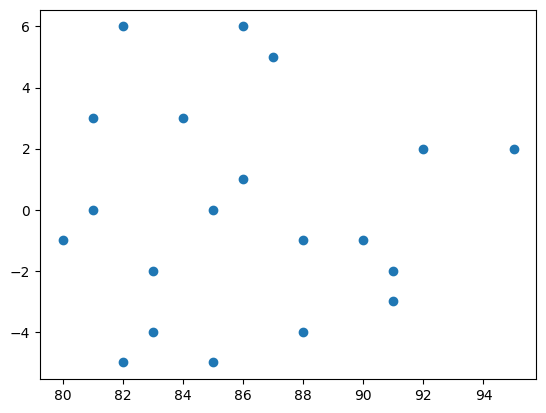

In [91]:
# Problem 1
df01 = pd.DataFrame({
    'raw_mat': np.repeat(np.arange(5)+1, 4),
    'operator': np.tile([i for i in 'ABCD'],5),
    'strength': (strength_Q1),
})
df01, df01_ANOVA, operator_f01, df01_NonAdd_ANOVA, nonadd_f01 = q1_anova(df01)

In [92]:
operator_f01, nonadd_f01

(np.float64(0.33865811618671526), np.float64(0.7608109850395327))

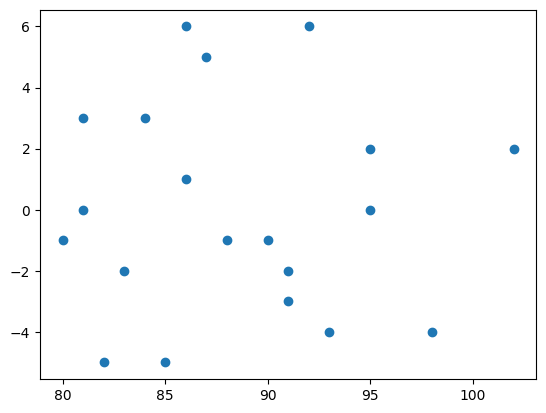

In [93]:
# Problem 2
strength_Q2 = strength_Q1.copy().reshape(5,4)
strength_Q2[:,3] += 10

df2 = pd.DataFrame({
    'raw_mat': np.repeat(np.arange(5)+1, 4),
    'operator': np.tile([i for i in 'ABCD'],5),
    'strength': (strength_Q2.flatten()),
})

df2, df2_ANOVA, operator_f2, df2_NonAdd_ANOVA, nonadd_f2 = q1_anova(df2)

In [94]:
operator_f2, nonadd_f2 # no nonadditive transformation. Operators differ

(np.float64(0.0036092642522950963), np.float64(0.9968720166822677))

In [86]:
df2_ANOVA

,sum_squares,dof,mean_square,ratio_mean_square
raw_mat_dev,264.0,4,66.000000,3.504425
operator_dev,445.0,3,148.333333,7.876106
residual,226.0,12,18.833333,1.000000


In [112]:
# find the scale and reference distributions for operators and plot the data 
# to identify which operator(s) is/are outliers

def gen_t_distri(df, df_ANOVA):

    operator_se = np.sqrt(df_ANOVA.loc['residual', 'mean_square'] / (df_ANOVA.loc['operator_dev', 'dof'] + 1))
    t_distri = stats.t.pdf(np.linspace(df['strength'].min(), df['strength'].max(), 1000),
                            df=(df_ANOVA.loc['operator_dev', 'dof'] + 1), loc=df['strength'].mean(), scale=operator_se)
    
    fig, ax = plt.subplots()
    ax.plot(np.linspace(df['strength'].min(), df['strength'].max(), 1000), t_distri)
    ax.scatter(df['operator_ave'].unique(), [0.005]*(df_ANOVA.loc['operator_dev', 'dof'] + 1))

    return fig, ax

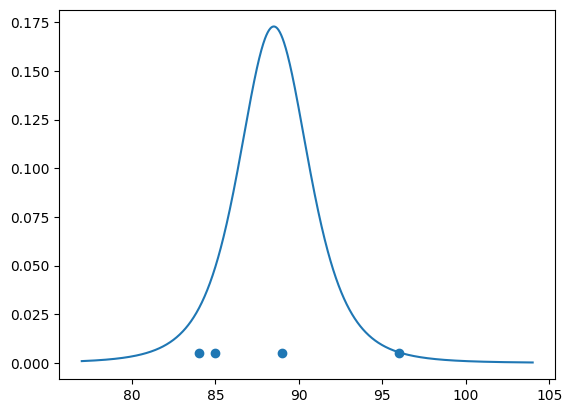

In [ ]:
fig2, ax2 = gen_t_distri(df2, df2_ANOVA)

In [119]:
# Problem 3
df3 = pd.DataFrame({
    'raw_mat': np.repeat(np.arange(5)+1, 4),
    'operator': np.tile([i for i in 'ABCD'],5),
    'strength': (strength_Q1),
})

df3.loc[df3['raw_mat']==3,'strength'] += 10

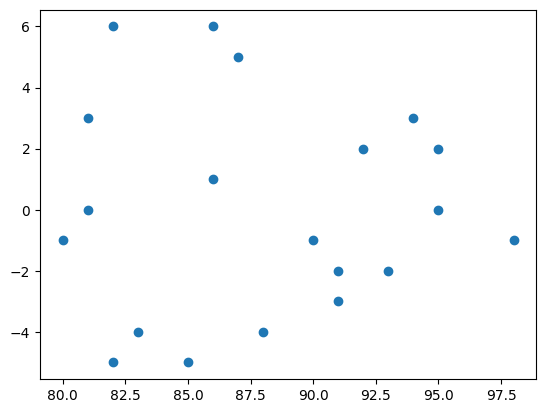

In [122]:
df3, df3_ANOVA, operator_f3, df3_NonAdd_ANOVA, nonadd_f3 = q1_anova(df3)

In [123]:
operator_f3, nonadd_f3

(np.float64(0.33865811618671526), np.float64(0.997801637309116))

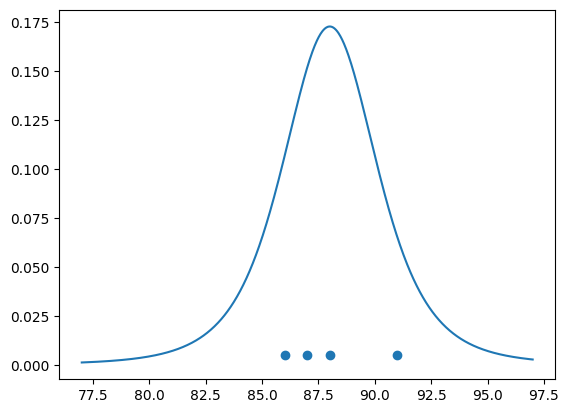

In [124]:
fig3, ax3 = gen_t_distri(df3, df3_ANOVA)

In [127]:
df4 = pd.DataFrame({
    'raw_mat': np.repeat(np.arange(5)+1, 4),
    'operator': np.tile([i for i in 'ABCD'],5),
    'strength': (strength_Q1),
})

df4.loc[(df4['operator'] == 'D') | (df4['raw_mat']==3), 'strength'] += 10

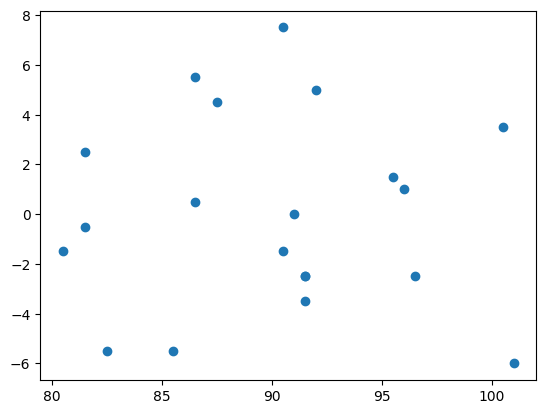

In [129]:
df4, df4_ANOVA, operator_f4, df4_NonAdd_ANOVA, nonadd_f4 = q1_anova(df4)

In [131]:
operator_f4, nonadd_f4

(np.float64(0.027440532804835507), np.float64(0.9792364797284052))

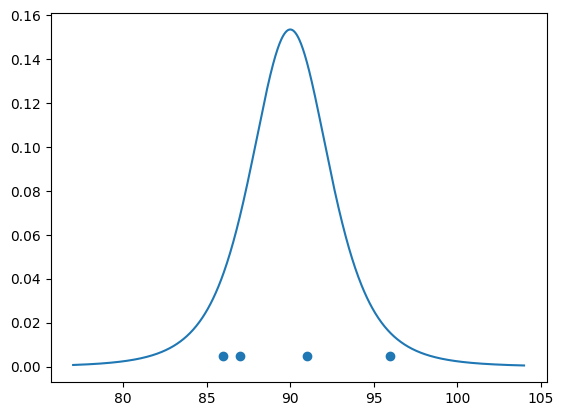

In [130]:
fig4, ax4 = gen_t_distri(df4, df4_ANOVA)

### Problem 5

In [146]:
df5 = pd.DataFrame({'treatment': [i for i in 'ABC']*16, 'test':np.array([0.38,0.53,0.51,0.26,0.35,0.63,0.41,0.38,0.46,0.33,0.45,0.47,0.33,1.09,0.42,0.37,0.46,0.45,0.54,0.57,0.41,0.76,0.47,0.39,0.51,0.39,0.35,0.55,0.74,0.41,0.53,0.32,0.49,0.41,0.74,0.4,0.47,0.48,0.58,0.49,0.37,0.46,0.42,0.52,0.38,0.34,0.44,0.48])})

In [161]:
df5.head()

,treatment,test,grand_ave,treatment_ave,treatment_dev,residual
0,A,0.38,0.472708,0.443750,-0.028958,-0.063750
1,B,0.53,0.472708,0.518750,0.046042,0.011250
2,C,0.51,0.472708,0.455625,-0.017083,0.054375
3,A,0.26,0.472708,0.443750,-0.028958,-0.183750
4,B,0.35,0.472708,0.518750,0.046042,-0.168750


In [147]:
df5['grand_ave'] = df5['test'].mean()
df5['treatment_ave'] = df5.groupby('treatment')['test'].transform('mean')
df5['treatment_dev'] = df5['treatment_ave'] - df5['grand_ave'] # or btw treatment deviations
df5['residual'] = df5['test'] - df5['treatment_ave'] # or called within treatment deviations

In [151]:
df5_ANOVA = (df5[['treatment_dev', 'residual']]**2).sum().to_frame(name='sum_squares')
df5_ANOVA['dof'] = [2,45]

In [153]:
df5_ANOVA['mean_square'] = df5_ANOVA['sum_squares'] / df5_ANOVA['dof']
df5_ANOVA['ratio_mean_square'] = df5_ANOVA['mean_square'] / df5_ANOVA.loc['residual', 'mean_square']

In [155]:
stats.f.sf(df5_ANOVA.loc['treatment_dev', 'ratio_mean_square'], dfn=2, dfd=45)

np.float64(0.2707265928303136)

(0.16, 1.1900000000000002)

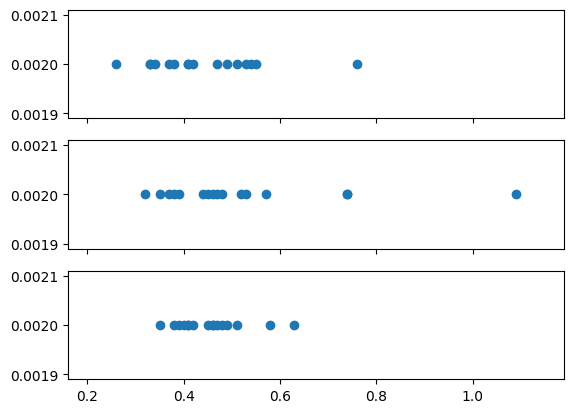

In [160]:
fig, ax = plt.subplots(3,1,sharex=True)
for i, k in enumerate('ABC'):
    ax[i].scatter(df5[df5['treatment']==k]['test'], [0.002]*16)
ax[0].set_xlim(df5['test'].min()-0.1, df5['test'].max()+0.1)


### Problem 6

In [187]:
df6 = pd.DataFrame({
    'lab': [i for i in 'ABC']*3+['B'],
    'result': [48,50,51,49,50,52,50,48,50,52]
})

In [190]:
df6['average'] = df6['result'].mean()
df6['lab_ave'] = df6.groupby('lab')['result'].transform('mean')
df6['lab_dev'] = df6['lab_ave'] - df6['average']
df6['residual'] = df6['result'] - df6['lab_ave']
df6

,lab,result,average,lab_ave,lab_dev,residual
0,A,48,50.0,49.0,-1.0,-1.0
1,B,50,50.0,50.0,0.0,0.0
2,C,51,50.0,51.0,1.0,0.0
3,A,49,50.0,49.0,-1.0,0.0
4,B,50,50.0,50.0,0.0,0.0
5,C,52,50.0,51.0,1.0,1.0
6,A,50,50.0,49.0,-1.0,1.0
7,B,48,50.0,50.0,0.0,-2.0
8,C,50,50.0,51.0,1.0,-1.0
9,B,52,50.0,50.0,0.0,2.0


In [198]:
df6_ANOVA = (df6[['average', 'lab_dev', 'residual']] ** 2).sum().to_frame(name='sum_squares')
df6_ANOVA['source'] = ['average','btw lab', 'within lab']
df6_ANOVA['dof'] = [1,2,7]
df6_ANOVA['mean_square'] = df6_ANOVA['sum_squares'] / df6_ANOVA['dof']
df6_ANOVA['ratio_mean_square'] = df6_ANOVA['mean_square'] / df6_ANOVA.loc['residual', 'mean_square']
df6_ANOVA

,sum_squares,source,dof,mean_square,ratio_mean_square
average,25000.0,average,1,25000.000000,14583.333333
lab_dev,6.0,btw lab,2,3.000000,1.750000
residual,12.0,within lab,7,1.714286,1.000000


In [199]:
stats.f.sf(1.75, dfn=2, dfd=7)

np.float64(0.2419249128674743)

the samples should be distributed randomly.

### Problem 7

In [210]:
df7 = pd.DataFrame({
    'source_var': ['blocks', 'treatments', 'residual'],
    'sum_squares': [534, 498, 40],
    'dof': [2,4,8],
})
df7['mean_square'] = df7['sum_squares'] / df7['dof']
df7['ratio_mean_square'] = df7['mean_square'] / df7.loc[2,'mean_square']
df7

,source_var,sum_squares,dof,mean_square,ratio_mean_square
0,blocks,534,2,267.0,53.4
1,treatments,498,4,124.5,24.9
2,residual,40,8,5.0,1.0


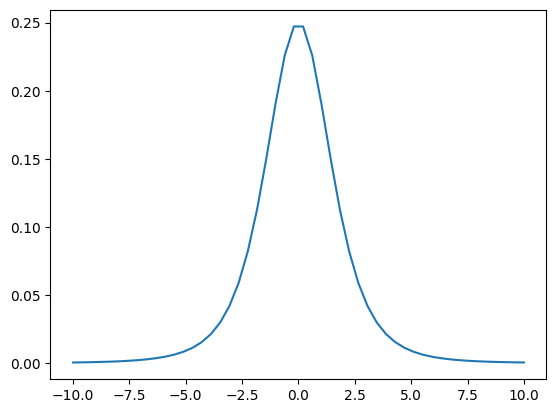

In [211]:
se7_treatment = np.sqrt(df7.loc[2,'mean_square'] / (df7.loc[1,'dof'])+1)
plt.plot(np.linspace(-10,10), stats.t.pdf(np.linspace(-10, 10), df=4, scale=se7_treatment))

### Problem 8
Latin square
assume randomized positions each run, runs are also randomized.

In [212]:
df8 = pd.DataFrame({
    'position': np.repeat([1,2,3,4],4),
    'run': np.tile(['I', 'II', 'III', 'IV'], 4),
    'area': [i for i in 'ADCBBADCCBADDCBA'],
    'result':[26.1,20.0,32.4,20.7,22.3,26.9,21.5,35,29,22.4,26.3,22.8,30.6,28.8,25.2,26.4]
})

df8

,position,run,area,result
0,1,I,A,26.1
1,1,II,D,20.0
2,1,III,C,32.4
3,1,IV,B,20.7
4,2,I,B,22.3
5,2,II,A,26.9
6,2,III,D,21.5
7,2,IV,C,35.0
8,3,I,C,29.0
9,3,II,B,22.4


In [214]:
df8['ave'] = df8['result'].mean()
df8['position_dev'] = df8.groupby('position')['result'].transform('mean') - df8.ave
df8['run_dev'] = df8.groupby('run')['result'].transform('mean') - df8.ave
df8['area_dev'] = df8.groupby('area')['result'].transform('mean') - df8.ave
df8['residual'] = df8['ave'] - df8['ave'] - df8['position_dev'] - df8['run_dev'] - df8['area_dev']
df8

,position,run,area,result,ave,position_dev,run_dev,area_dev,residual
0,1,I,A,26.1,26.025,-1.225,0.975,0.400,-0.150
1,1,II,D,20.0,26.025,-1.225,-1.500,-2.300,5.025
2,1,III,C,32.4,26.025,-1.225,0.325,5.275,-4.375
3,1,IV,B,20.7,26.025,-1.225,0.200,-3.375,4.400
4,2,I,B,22.3,26.025,0.400,0.975,-3.375,2.000
5,2,II,A,26.9,26.025,0.400,-1.500,0.400,0.700
6,2,III,D,21.5,26.025,0.400,0.325,-2.300,1.575
7,2,IV,C,35.0,26.025,0.400,0.200,5.275,-5.875
8,3,I,C,29.0,26.025,-0.900,0.975,5.275,-5.350
9,3,II,B,22.4,26.025,-0.900,-1.500,-3.375,5.775


In [216]:
df8_ANOVA = (df8[['position_dev', 'run_dev', 'area_dev', 'residual']]**2).sum().to_frame(name='sum_squares')
df8_ANOVA['dof'] = [3,3,3,6]
df8_ANOVA['mean_square'] = df8_ANOVA['sum_squares'] / df8_ANOVA['dof']
df8_ANOVA['ratio_mean_square'] = df8_ANOVA['mean_square'] / df8_ANOVA.loc['residual','mean_square']
df8_ANOVA

,sum_squares,dof,mean_square,ratio_mean_square
position_dev,21.785,3,7.261667,0.203755
run_dev,13.385,3,4.461667,0.125190
area_dev,178.665,3,59.555000,1.671055
residual,213.835,6,35.639167,1.000000


In [217]:
stats.f.sf(1.67,dfn=3,dfd=6)

np.float64(0.27120228422824993)

### Problem 9
One more assumption: the order of the five operators run the test is also randomized

In [219]:
df9 = pd.DataFrame({
    'day': np.repeat([i for i in'TWF'], 5),
    'operator': [i for i in 'ABCDE']*3,
    'result': [509,512,532,506,509,505,507,542,520,519,465,472,498,483,475]
})

df9['ave'] = df9.result.mean()
df9['day_dev'] = df9.groupby('day')['result'].transform('mean') - df9['ave']
df9['operator_dev'] = df9.groupby('operator')['result'].transform('mean') - df9['ave']

df9['residual'] = df9['result'] - df9['ave'] - df9['day_dev'] - df9['operator_dev']

df9

,day,operator,result,ave,day_dev,operator_dev,residual
0,T,A,509,503.6,10.0,-10.6,6.0
1,T,B,512,503.6,10.0,-6.6,5.0
2,T,C,532,503.6,10.0,20.4,-2.0
3,T,D,506,503.6,10.0,-0.6,-7.0
4,T,E,509,503.6,10.0,-2.6,-2.0
5,W,A,505,503.6,15.0,-10.6,-3.0
6,W,B,507,503.6,15.0,-6.6,-5.0
7,W,C,542,503.6,15.0,20.4,3.0
8,W,D,520,503.6,15.0,-0.6,2.0
9,W,E,519,503.6,15.0,-2.6,3.0


In [222]:
df9_ANOVA = (df9[df9.columns[-3:]]**2).sum().to_frame(name='sum_squares')
df9_ANOVA['dof'] = [2,4,8]
df9_ANOVA['mean_square'] = df9_ANOVA['sum_squares'] / df9_ANOVA['dof']
df9_ANOVA['ratio_mean_square'] = df9_ANOVA['mean_square'] / df9_ANOVA.loc['residual', 'mean_square']

df9_ANOVA

,sum_squares,dof,mean_square,ratio_mean_square
day_dev,4750.0,2,2375.00,90.476190
operator_dev,1737.6,4,434.40,16.548571
residual,210.0,8,26.25,1.000000


In [224]:
stats.f.sf(16.548571, dfn=4, dfd=8) # significant differences among operators

np.float64(0.0006175481004275237)

In [226]:
se9_operator = np.sqrt(df9_ANOVA.loc['residual', 'mean_square'] / 5)
se9_operator

np.float64(2.29128784747792)

[Text(493.0, 0.005, 'A'),
 Text(497.0, 0.005, 'B'),
 Text(524.0, 0.005, 'C'),
 Text(503.0, 0.005, 'D'),
 Text(501.0, 0.005, 'E')]

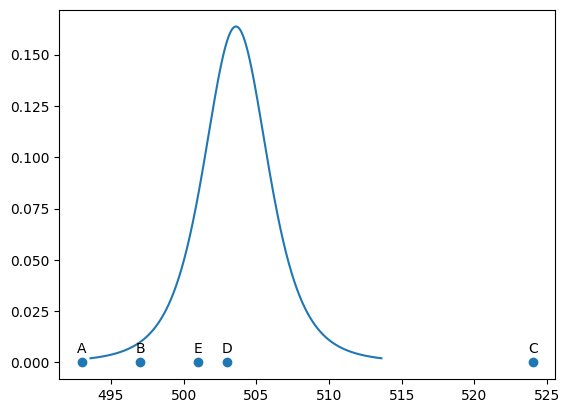

In [247]:
plt.plot(np.linspace(-10,10,1001) + df9.result.mean(), stats.t.pdf(np.linspace(-10,10,1001), df=4, scale=se9_operator))
plt.scatter(df9.groupby('operator')['result'].mean().values, [0]*5)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df9.groupby('operator')['result'].mean().values, [0.005]*5, df9.groupby('operator')['result'].mean().index)]

In [256]:
# blocking seems not worthwhile based on the following analysis
df9d = pd.DataFrame({
    # 'day': np.repeat([i for i in'TWF'], 5),
    'operator': [i for i in 'ABCDE']*3,
    'result': [509,512,532,506,509,505,507,542,520,519,465,472,498,483,475]
})

df9d['ave'] = df9d.result.mean()
df9d['operator_dev'] = df9d.groupby('operator')['result'].transform('mean') - df9d['ave']

df9d['residual'] = df9d['result'] - df9d['ave'] - df9d['operator_dev']

df9d

,operator,result,ave,operator_dev,residual
0,A,509,503.6,-10.6,16.0
1,B,512,503.6,-6.6,15.0
2,C,532,503.6,20.4,8.0
3,D,506,503.6,-0.6,3.0
4,E,509,503.6,-2.6,8.0
5,A,505,503.6,-10.6,12.0
6,B,507,503.6,-6.6,10.0
7,C,542,503.6,20.4,18.0
8,D,520,503.6,-0.6,17.0
9,E,519,503.6,-2.6,18.0


In [257]:
df9d_ANOVA = (df9[df9.columns[-2:]]**2).sum().to_frame(name='sum_squares')
df9d_ANOVA['dof'] = [4,10]
df9d_ANOVA['mean_square'] = df9d_ANOVA['sum_squares'] / df9d_ANOVA['dof']
df9d_ANOVA['ratio_mean_square'] = df9d_ANOVA['mean_square'] / df9d_ANOVA.loc['residual', 'mean_square']

df9d_ANOVA

,sum_squares,dof,mean_square,ratio_mean_square
operator_dev,1737.6,4,434.4,20.685714
residual,210.0,10,21.0,1.000000


In [258]:
stats.f.sf(20.685714, dfn=4, dfd=10)

np.float64(7.959025570817015e-05)

In [259]:
se9d_operator = np.sqrt(df9d_ANOVA.loc['residual', 'mean_square'] / 5)
se9d_operator

np.float64(2.04939015319192)

[Text(493.0, 0.005, 'A'),
 Text(497.0, 0.005, 'B'),
 Text(524.0, 0.005, 'C'),
 Text(503.0, 0.005, 'D'),
 Text(501.0, 0.005, 'E')]

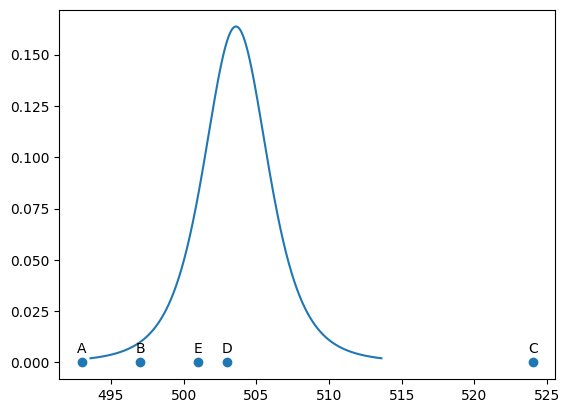

In [260]:
plt.plot(np.linspace(-10,10,1001) + df9d.result.mean(), stats.t.pdf(np.linspace(-10,10,1001), df=4, scale=se9_operator))
plt.scatter(df9d.groupby('operator')['result'].mean().values, [0]*5)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df9d.groupby('operator')['result'].mean().values, [0.005]*5, df9d.groupby('operator')['result'].mean().index)]

### Problem 10 

(0.0, 10.0)

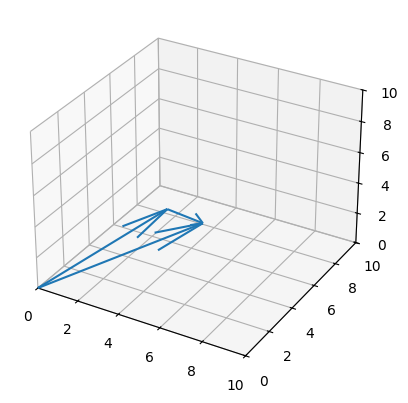

In [273]:
# plot vectors
fig10 = plt.figure()
ax10 = fig10.add_subplot(projection='3d')

# define 3 vectors
# d = yA - yB
d10_x, d10_y, d10_z = np.array([0,0,0]) # d vector start and d_bar start
d10_u, d10_v, d10_w = np.array([4,7,1]) # d vector direction
d10_bar_u, d10_bar_v, d10_bar_w = np.array([4,4,4]) # d_bar direction and d-d_bar start
dd10_u, dd10_v, dd10_w = np.array([0,3,-3]) # d-d_bar direction

ax10.quiver(d10_x, d10_y, d10_z, d10_u, d10_v, d10_w)
ax10.quiver(d10_x, d10_y, d10_z, d10_bar_u, d10_bar_v, d10_bar_w)
ax10.quiver(d10_bar_u, d10_bar_v, d10_bar_w, dd10_u, dd10_v, dd10_w )

ax10.set_xlim(0,10)
ax10.set_ylim(0,10)
ax10.set_zlim(0,10)


In [309]:
# paired t test
dd10 = np.array([4,7,1]) # treatment differences
stats.t.sf(dd10.mean(), scale=dd10.std(ddof=1)/np.sqrt(3), df=2) * 2, (dd10.mean()-0)/dd10.std(ddof=1)*np.sqrt(3) 


(np.float64(0.14719713457755826), np.float64(2.309401076758503))

In [287]:
# 95% confidence level
stats.t.isf(0.025, scale=dd10.std(ddof=1)/np.sqrt(3), df=2), stats.t.isf(0.975, scale=dd10.std(ddof=1)/np.sqrt(3), df=2)

(np.float64(7.452413135158641), np.float64(-7.452413135158637))

In [303]:
# ANOVA
df10 = pd.DataFrame({
    'block': np.repeat([1,2,3],2),
    'treatment': ['A', 'B']*3,
    'result': [16,12,23,16,30,29]
})

df10['ave'] = df10['result'].mean()
df10['block_dev'] = df10.groupby('block')['result'].transform('mean') - df10['ave']
df10['treatment_dev'] = df10.groupby('treatment')['result'].transform('mean') - df10['ave']
df10['residual'] = df10['result'] - df10['ave'] - df10['block_dev'] - df10['treatment_dev']
# df10['residual'] = df10['result'] - df10['ave'] - df10['treatment_dev']

df10

,block,treatment,result,ave,block_dev,treatment_dev,residual
0,1,A,16,21.0,-7.0,2.0,0.0
1,1,B,12,21.0,-7.0,-2.0,0.0
2,2,A,23,21.0,-1.5,2.0,1.5
3,2,B,16,21.0,-1.5,-2.0,-1.5
4,3,A,30,21.0,8.5,2.0,-1.5
5,3,B,29,21.0,8.5,-2.0,1.5


In [305]:
df10_ANOVA = (df10[df10.columns[-3:]]**2).sum().to_frame(name='sum_squares')
df10_ANOVA['dof'] = [2,1,2]
df10_ANOVA['mean_square'] = df10_ANOVA['sum_squares'] / df10_ANOVA['dof']
df10_ANOVA['ratio_mean_square'] = df10_ANOVA['mean_square'] / df10_ANOVA.loc['residual', 'mean_square']

df10_ANOVA

,sum_squares,dof,mean_square,ratio_mean_square
block_dev,247.0,2,123.5,27.444444
treatment_dev,24.0,1,24.0,5.333333
residual,9.0,2,4.5,1.000000


In [306]:
# f score
stats.f.sf(5.33333333, dfn=1, dfd=2)

np.float64(0.14719713465024034)

In [302]:
# use the scipy functions ttest_rel and f test
stats.ttest_rel(df10[df10['treatment']=='A']['result'].values, df10[~(df10['treatment']=='A')]['result'].values)

TtestResult(statistic=np.float64(2.3094010767585034), pvalue=np.float64(0.1471971345775582), df=np.int64(2))

In [307]:
stats.f_oneway(df10[df10['treatment']=='A']['result'].values, df10[~(df10['treatment']=='A')]['result'].values) # one-way ANOVA f test, meaning ignore blocks

F_onewayResult(statistic=np.float64(0.375), pvalue=np.float64(0.5733922538253552))

### Problem 11

In [13]:
df11 = pd.DataFrame({
    'machine': np.repeat([1,2,3,4,5],8),
    'operator': [i for i in 'AABBCCDD']*5,
    'day': [9,76,11,77,22,72,3,73,1,71,3,73,57,70,2,78,3,77,7,70,25,73,33,72,2,72,4,74,5,71,6,75,17,84,10,72,39,74,7,82],
    'result': [18,17,16,18,17,20,27,27,17,13,18,18,20,16,28,23,16,17,17,19,20,16,31,30,15,17,21,22,16,16,31,24,17,18,16,18,14,13,28,22]
})

df11

,machine,operator,day,result
0,1,A,9,18
1,1,A,76,17
2,1,B,11,16
3,1,B,77,18
4,1,C,22,17
5,1,C,72,20
6,1,D,3,27
7,1,D,73,27
8,2,A,1,17
9,2,A,71,13


In [14]:
# assume no difference among operators and machines
df11['ave'] = df11['result'].mean()
df11['machine_dev'] = df11.groupby('machine')['result'].transform('mean') - df11['ave']
df11['operator_dev'] = df11.groupby('operator')['result'].transform('mean') - df11['ave']
df11['residual'] = df11['result'] - df11['ave'] - df11['machine_dev'] - df11['operator_dev']

df11

,machine,operator,day,result,ave,machine_dev,operator_dev,residual
0,1,A,9,18,19.675,0.325,-3.175,1.175
1,1,A,76,17,19.675,0.325,-3.175,0.175
2,1,B,11,16,19.675,0.325,-1.375,-2.625
3,1,B,77,18,19.675,0.325,-1.375,-0.625
4,1,C,22,17,19.675,0.325,-2.875,-0.125
5,1,C,72,20,19.675,0.325,-2.875,2.875
6,1,D,3,27,19.675,0.325,7.425,-0.425
7,1,D,73,27,19.675,0.325,7.425,-0.425
8,2,A,1,17,19.675,-0.550,-3.175,1.050
9,2,A,71,13,19.675,-0.550,-3.175,-2.950


In [4]:
df11_ANOVA = (df11[df11.columns[-3:]]**2).sum().to_frame(name='sum_squares')
df11_ANOVA['dof'] = [4, 3, 32]
df11_ANOVA['mean_square'] = df11_ANOVA['sum_squares'] / df11_ANOVA['dof']
df11_ANOVA['raito_mean_square'] = df11_ANOVA['mean_square'] / df11_ANOVA.loc['residual', 'mean_square']

df11_ANOVA

,sum_squares,dof,mean_square,raito_mean_square
machine_dev,31.400,4,7.850000,1.463017
operator_dev,753.675,3,251.225000,46.821200
residual,171.700,32,5.365625,1.000000


In [5]:
stats.f.sf(46.8212, dfn=3, dfd=32), stats.f.sf(1.463017, dfn=4, dfd=32) # operator and machine differences f test

(np.float64(8.280234184650128e-12), np.float64(0.23645743903559932))

[Text(16.5, 0.02, 'A'),
 Text(18.3, 0.02, 'B'),
 Text(16.8, 0.02, 'C'),
 Text(27.1, 0.02, 'D')]

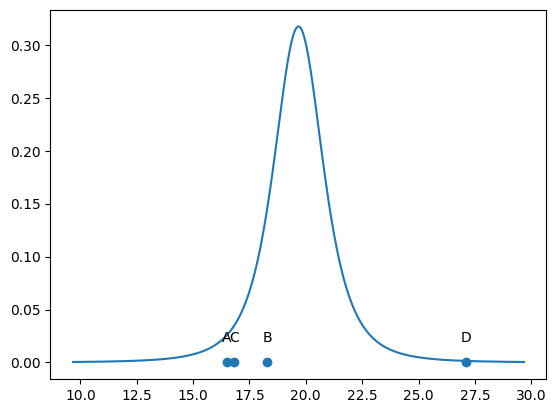

In [6]:
# operator ref t distribution
se11_operator = np.sqrt(df11_ANOVA.loc['residual','mean_square']/4)
plt.plot(np.linspace(-10,10,1001)+df11['result'].mean(), stats.t.pdf(np.linspace(-10,10,1001), df=3, scale=se11_operator))
plt.scatter(df11.groupby('operator')['result'].mean().values, [0.00]*4)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df11.groupby('operator')['result'].mean().values, [0.02]*4, df11.groupby('operator')['result'].mean().index)]

[Text(20.0, 0.02, '1'),
 Text(19.125, 0.02, '2'),
 Text(20.75, 0.02, '3'),
 Text(20.25, 0.02, '4'),
 Text(18.25, 0.02, '5')]

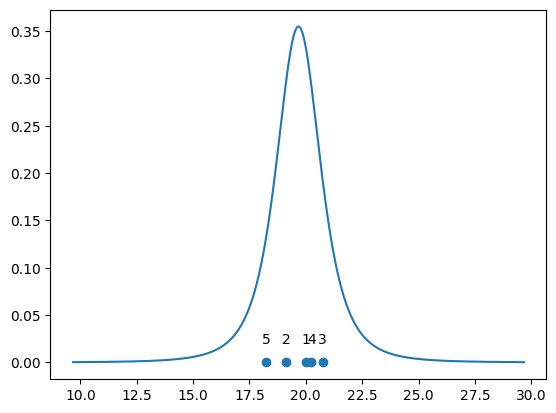

In [7]:
# machine ref t distribution
se11_machine = np.sqrt(df11_ANOVA.loc['residual','mean_square']/5)
plt.plot(np.linspace(-10,10,1001)+df11['result'].mean(), stats.t.pdf(np.linspace(-10,10,1001), df=3, scale=se11_machine))
plt.scatter(df11.groupby('machine')['result'].mean().values, [0.00]*5)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df11.groupby('machine')['result'].mean().values, [0.02]*5, df11.groupby('machine')['result'].mean().index)]

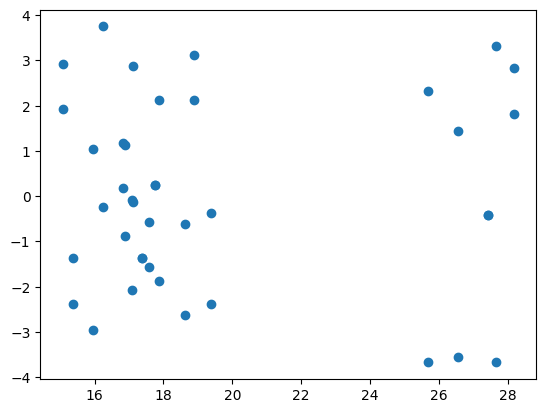

In [8]:
plt.scatter(df11[['ave', 'machine_dev', 'operator_dev']].sum(axis=1), df11['residual'])

In [20]:
df11['predicted'] = df11[['ave', 'machine_dev', 'operator_dev']].sum(axis=1)
df11['q'] = df11['predicted']**2
df11['q_ave'] = df11['q'].mean()
df11['q_machine_dev'] = df11.groupby('machine')['q'].transform('mean') - df11['q_ave']
df11['q_operator_dev'] = df11.groupby('operator')['q'].transform('mean') - df11['q_ave']
df11['q_predicted'] = df11[['q_ave', 'q_machine_dev', 'operator_dev']].sum(axis=1)

# check nonadditive transformation
P11 = ((df11['result'] - df11['predicted'])*(df11['q'] - df11['q_predicted'])).sum()
Q11 = ((df11['q'] - df11['q_predicted'])**2).sum()
Sna11 = P11 ** 2 / Q11
Sna11 

np.float64(0.017648100340310533)

In [21]:
df11_ANOVA

,sum_squares,dof,mean_square,raito_mean_square
machine_dev,31.400,4,7.850000,1.463017
operator_dev,753.675,3,251.225000,46.821200
residual,171.700,32,5.365625,1.000000


In [23]:
stats.f.sf(0.0177/171.7*31, dfn=1, dfd=31) # check nanadditive transformation using f test

np.float64(0.9552820472984153)

[Text(16.5, 0.02, 'A'),
 Text(18.3, 0.02, 'B'),
 Text(16.8, 0.02, 'C'),
 Text(27.1, 0.02, 'D')]

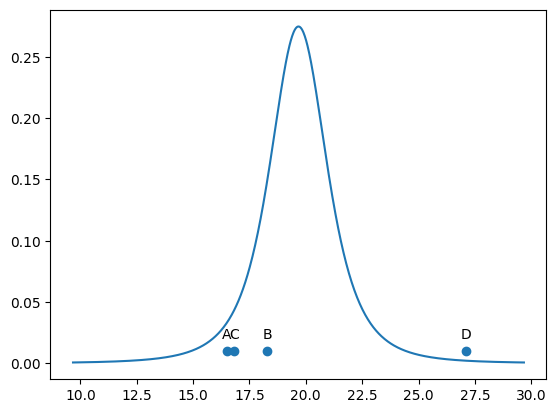

In [9]:
# operator ref t distribution
se11_operator = np.sqrt(df11_ANOVA.loc['residual','mean_square']/3)
plt.plot(np.linspace(-10,10,1001)+df11['result'].mean(), stats.t.pdf(np.linspace(-10,10,1001), df=3, scale=se11_operator))
plt.scatter(df11.groupby('operator')['result'].mean().values, [0.01]*4)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df11.groupby('operator')['result'].mean().values, [0.02]*4, df11.groupby('operator')['result'].mean().index)]

### Problem 12

In [15]:
df12 = df11[df11['day']<=60].copy()
# assume no difference among operators and machines
df12['ave'] = df12['result'].mean()
df12['machine_dev'] = df12.groupby('machine')['result'].transform('mean') - df12['ave']
df12['operator_dev'] = df12.groupby('operator')['result'].transform('mean') - df12['ave']
df12['residual'] = df12['result'] - df12['ave'] - df12['machine_dev'] - df12['operator_dev']

df12

,machine,operator,day,result,ave,machine_dev,operator_dev,residual
0,1,A,9,18,20.15,-0.65,-3.55,2.05
2,1,B,11,16,20.15,-0.65,-2.55,-0.95
4,1,C,22,17,20.15,-0.65,-2.75,0.25
6,1,D,3,27,20.15,-0.65,8.85,-1.35
8,2,A,1,17,20.15,0.60,-3.55,-0.20
10,2,B,3,18,20.15,0.60,-2.55,-0.20
12,2,C,57,20,20.15,0.60,-2.75,2.00
14,2,D,2,28,20.15,0.60,8.85,-1.60
16,3,A,3,16,20.15,0.85,-3.55,-1.45
18,3,B,7,17,20.15,0.85,-2.55,-1.45


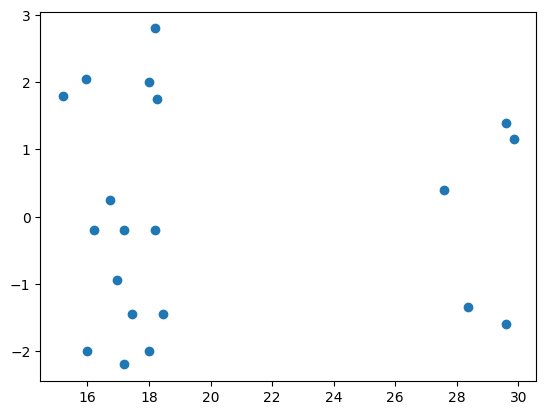

In [16]:
plt.scatter(df12[['ave', 'machine_dev', 'operator_dev']].sum(axis=1), df12['residual'])

In [17]:
df12['predicted'] = df12[['ave', 'machine_dev', 'operator_dev']].sum(axis=1)
df12['q'] = df12['predicted']**2
df12['q_ave'] = df12['q'].mean()
df12['q_machine_dev'] = df12.groupby('machine')['q'].transform('mean') - df12['q_ave']
df12['q_operator_dev'] = df12.groupby('operator')['q'].transform('mean') - df12['q_ave']
df12['q_predicted'] = df12[['q_ave', 'q_machine_dev', 'operator_dev']].sum(axis=1)

df12


,machine,operator,day,result,ave,machine_dev,operator_dev,residual,predicted,q,q_ave,q_machine_dev,q_operator_dev,q_predicted
0,1,A,9,18,20.15,-0.65,-3.55,2.05,15.95,254.4025,433.035,-26.5375,-156.71,402.9475
2,1,B,11,16,20.15,-0.65,-2.55,-0.95,16.95,287.3025,433.035,-26.5375,-122.51,403.9475
4,1,C,22,17,20.15,-0.65,-2.75,0.25,16.75,280.5625,433.035,-26.5375,-129.51,403.7475
6,1,D,3,27,20.15,-0.65,8.85,-1.35,28.35,803.7225,433.035,-26.5375,408.73,415.3475
8,2,A,1,17,20.15,0.60,-3.55,-0.20,17.20,295.8400,433.035,23.7750,-156.71,453.2600
10,2,B,3,18,20.15,0.60,-2.55,-0.20,18.20,331.2400,433.035,23.7750,-122.51,454.2600
12,2,C,57,20,20.15,0.60,-2.75,2.00,18.00,324.0000,433.035,23.7750,-129.51,454.0600
14,2,D,2,28,20.15,0.60,8.85,-1.60,29.60,876.1600,433.035,23.7750,408.73,465.6600
16,3,A,3,16,20.15,0.85,-3.55,-1.45,17.45,304.5025,433.035,34.2125,-156.71,463.6975
18,3,B,7,17,20.15,0.85,-2.55,-1.45,18.45,340.4025,433.035,34.2125,-122.51,464.6975


In [25]:
df12_ANOVA = (df12[['machine_dev', 'operator_dev', 'residual']]**2).sum().to_frame(name='sum_square')
df12_ANOVA['dof'] = [4,3,12]
df12_ANOVA['mean_square'] = df12_ANOVA['sum_square'] / df12_ANOVA['dof']
df12_ANOVA['ratio_mean_square'] = df12_ANOVA['mean_square'] / df12_ANOVA.loc['residual', 'mean_square']
df12_ANOVA

,sum_square,dof,mean_square,ratio_mean_square
machine_dev,15.30,4,3.825000,0.950311
operator_dev,524.95,3,174.983333,43.474120
residual,48.30,12,4.025000,1.000000


In [26]:
# f test: machine then operator
stats.f.sf(0.950311, dfn=4, dfd=12), stats.f.sf(43.47412, dfn=3, dfd=12)

(np.float64(0.4687419139133203), np.float64(1.0106238183495287e-06))

In [ ]:
# check nonadditive transformation
P12 = ((df12['result'] - df12['predicted'])*(df12['q'] - df12['q_predicted'])).sum()
Q12 = ((df12['q'] - df12['q_predicted'])**2).sum()
Sna12 = P12 ** 2 / Q12
Sna12 

np.float64(0.001362159385845356)

In [27]:
stats.f.sf(Sna12/48.3*11, dfn=1, dfd=11)

np.float64(0.9862628879141196)

[Text(19.5, 0.02, '1'),
 Text(20.75, 0.02, '2'),
 Text(21.0, 0.02, '3'),
 Text(20.75, 0.02, '4'),
 Text(18.75, 0.02, '5')]

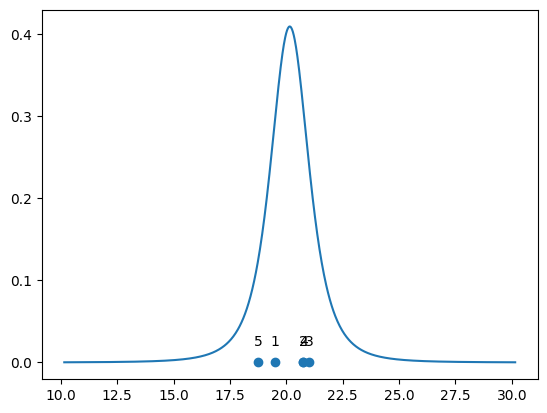

In [28]:
# machine ref t distribution
se12_machine = np.sqrt(df12_ANOVA.loc['residual','mean_square']/5)
plt.plot(np.linspace(-10,10,1001)+df12['result'].mean(), stats.t.pdf(np.linspace(-10,10,1001), df=3, scale=se12_machine))
plt.scatter(df12.groupby('machine')['result'].mean().values, [0.00]*5)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df12.groupby('machine')['result'].mean().values, [0.02]*5, df12.groupby('machine')['result'].mean().index)]

[Text(16.6, 0.02, 'A'),
 Text(17.6, 0.02, 'B'),
 Text(17.4, 0.02, 'C'),
 Text(29.0, 0.02, 'D')]

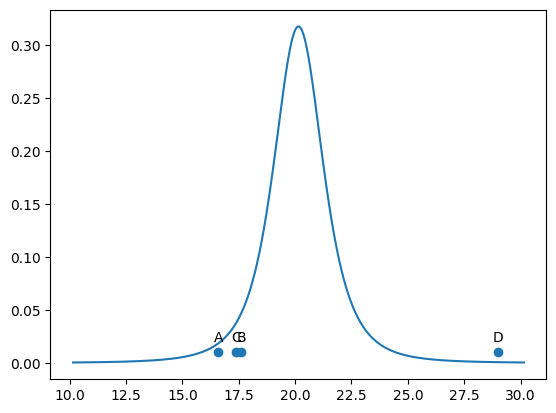

In [29]:
# operator ref t distribution
se12_operator = np.sqrt(df12_ANOVA.loc['residual','mean_square']/3)
plt.plot(np.linspace(-10,10,1001)+df12['result'].mean(), stats.t.pdf(np.linspace(-10,10,1001), df=3, scale=se12_operator))
plt.scatter(df12.groupby('operator')['result'].mean().values, [0.01]*4)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df12.groupby('operator')['result'].mean().values, [0.02]*4, df12.groupby('operator')['result'].mean().index)]

### Problem 13
the corrosion test order should be randomized

In [31]:
df13 = pd.DataFrame({
    'source_var': ['ave', 'btw_t', 'within_t'],
    'sum_squares': [213363.33,77.58,59.09],
    'dof': [1,3,26],
}).set_index('source_var')
df13['mean_square'] = df13['sum_squares'] / df13['dof']
df13['ratio_mean_square'] = df13['mean_square'] / df13.loc['within_t', 'mean_square']

df13

,sum_squares,dof,mean_square,ratio_mean_square
source_var,,,,
ave,213363.33,1,213363.330000,93881.309528
btw_t,77.58,3,25.860000,11.378575
within_t,59.09,26,2.272692,1.000000


In [32]:
# f test
stats.f.sf(11.378575, dfn=3, dfd=26)

np.float64(5.970265479329864e-05)

In [34]:
df13b = pd.DataFrame({
    'metal': [i for i in 'ABCD'],
    'sample_size': [7,8,8,7],
    'treatment_ave': [86.143, 85.75,82.625,82.857]
})
df13b

,metal,sample_size,treatment_ave
0,A,7,86.143
1,B,8,85.750
2,C,8,82.625
3,D,7,82.857


In [37]:
df13_ave = (df13b['sample_size'] * df13b['treatment_ave']).sum() / df13b['sample_size'].sum()
df13_ave

np.float64(84.33333333333333)

[Text(86.143, 0.02, 'A'),
 Text(85.75, 0.02, 'B'),
 Text(82.625, 0.02, 'C'),
 Text(82.857, 0.02, 'D')]

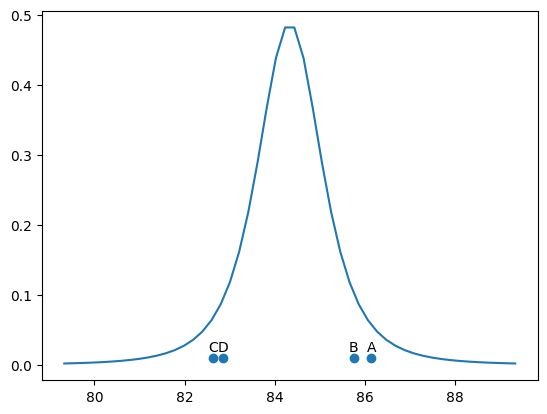

In [43]:
range13 = 5
plt.plot(np.linspace(-range13, range13) + df13_ave, stats.t.pdf(np.linspace(-range13, range13), df=3, scale=np.sqrt(df13.loc['within_t', 'mean_square']/4)))
plt.scatter(df13b['treatment_ave'], [0.01]*4)
[plt.text(x,y,s, ha='center') for x,y,s in zip(df13b['treatment_ave'], [0.02]*4, df13b['metal'])]

In [59]:
# c
ave13c = df13b['treatment_ave'].diff(-2).sum()/2
stats.t.sf(ave13c, df=26, scale=np.sqrt((1/2)**2 * df13.loc['within_t', 'mean_square']*(1/7+1/8+1/8+1/7)))

np.float64(2.0113557040577886e-06)

In [61]:
# population var
var13c_p = df13.loc['within_t', 'mean_square']
# sample mean var for A, B, C, D assuming no difference and just 4 samples from the same population
var13c_A, var13c_B, var13c_C, var13c_D = var13c_p / 7, var13c_p / 8, var13c_p / 8, var13c_p / 7
var13c = (1/2)**2 * (var13c_A + var13c_B + var13c_C + var13c_D)
# sample mean standard error
se13c = np.sqrt(var13c)
# t test
stats.t.sf(ave13c, df=26 , scale=se13c)

np.float64(2.0113557040577886e-06)

### Problem 14

In [174]:
# a blocked randomization design
# different floor tiles are blocks
# different instruments are treatments
# design is shown below
# test floor tiles one by one as blocks
# within each block, randomize the order of testing with the 3 instruments
# assume random errors
df14 = pd.DataFrame({
    'floor_tile': np.repeat(['A', 'B', 'C'], 3),
    'instrument': ['I', 'II', 'III'] * 3,
    'result': [np.nan] * 9
})
df14

,floor_tile,instrument,result
0,A,I,NaN
1,A,II,NaN
2,A,III,NaN
3,B,I,NaN
4,B,II,NaN
5,B,III,NaN
6,C,I,NaN
7,C,II,NaN
8,C,III,NaN


In [175]:
# c generate random data
# model: y = y_bar + dev_b + dev_t + error
y_bar14 = 50
dev_b14 = np.repeat([3,-2,-1], 3)
dev_t14 = np.tile([3,-2,-9], 3)
error14 = np.array([stats.norm.rvs(scale=5) for _ in range(9)])
df14['result'] = y_bar14 + dev_b14 + dev_t14 + error14
df14

,floor_tile,instrument,result
0,A,I,48.231883
1,A,II,50.133177
2,A,III,44.799261
3,B,I,48.090136
4,B,II,44.252101
5,B,III,33.023787
6,C,I,51.847407
7,C,II,37.140675
8,C,III,36.217160


In [176]:
df14['ave'] = df14['result'].mean()
df14['tile_dev'] = df14.groupby('floor_tile')['result'].transform('mean') - df14['ave']
df14['instr_dev'] = df14.groupby('instrument')['result'].transform('mean') - df14['ave']
df14['residual'] = df14['result'] - df14['ave'] - df14['tile_dev'] - df14['instr_dev']
df14

,floor_tile,instrument,result,ave,tile_dev,instr_dev,residual
0,A,I,48.231883,43.748399,3.973042,5.641410,-5.130967
1,A,II,50.133177,43.748399,3.973042,0.093586,2.318151
2,A,III,44.799261,43.748399,3.973042,-5.734996,2.812817
3,B,I,48.090136,43.748399,-1.959724,5.641410,0.660051
4,B,II,44.252101,43.748399,-1.959724,0.093586,2.369840
5,B,III,33.023787,43.748399,-1.959724,-5.734996,-3.029892
6,C,I,51.847407,43.748399,-2.013318,5.641410,4.470916
7,C,II,37.140675,43.748399,-2.013318,0.093586,-4.687991
8,C,III,36.217160,43.748399,-2.013318,-5.734996,0.217075


In [177]:
df14_ANOVA = (df14[['tile_dev', 'instr_dev', 'residual']]**2).sum().to_frame(name='sum_squares')
df14_ANOVA['dof'] = [2,2,4]
df14_ANOVA['mean_square'] = df14_ANOVA['sum_squares'] / df14_ANOVA['dof']
df14_ANOVA['ratio_mean_square'] = df14_ANOVA['mean_square'] / df14_ANOVA.loc['residual', 'mean_square']
df14_ANOVA

,sum_squares,dof,mean_square,ratio_mean_square
tile_dev,71.037088,2,35.518544,1.466828
instr_dev,194.173327,2,97.086663,4.009438
residual,96.858117,4,24.214529,1.000000


In [178]:
stats.f.sf(df14_ANOVA.loc['instr_dev','ratio_mean_square'], dfn=2, dfd=4)

np.float64(0.1107623638508437)

[Text(49.38980865127879, 0.005, 'I'),
 Text(43.841984433426774, 0.005, 'II'),
 Text(38.01340282643789, 0.005, 'III')]

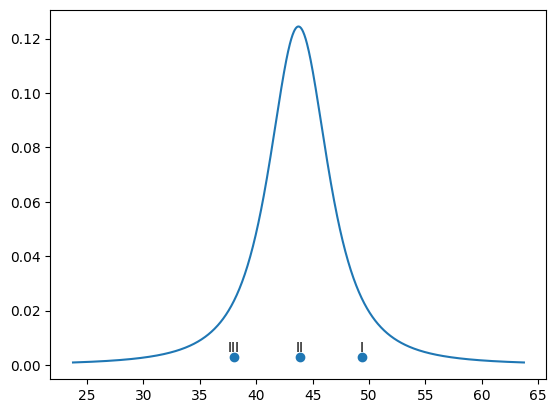

In [179]:
range14 = 20
plt.plot(np.linspace(-range14, range14, 1001) + df14['result'].mean(), stats.t.pdf(np.linspace(-range14, range14, 1001), df=2, scale=np.sqrt(df14_ANOVA.loc['residual', 'mean_square']/3)))
plt.scatter(df14.groupby('instrument')['result'].mean().values, [0.003]*3)
[plt.text(x,y,s,ha='center') for x,y,s in zip(df14.groupby('instrument')['result'].mean().values, [0.005]*3, df14.groupby('instrument')['result'].mean().index)]

In [180]:
df14.groupby('instrument')['result'].mean().index

Index(['I', 'II', 'III'], dtype='object', name='instrument')

### Problem 15 Latin Square design


In [193]:
def get_square(seq: list, n, m, i=1):
    '''seq: sequence with the length equal m, the number of cols. 
    n is the number of rows. i is the number to shift the initial seq btw rows (default i=1)'''
    seq_arr = np.array([(np.arange(m) + i) % n for i in range(n)])
    row_order, col_order = np.arange(n), np.arange(m)
    np.random.shuffle(row_order)
    np.random.shuffle(col_order)
    seq_arr = seq_arr[:,col_order][row_order,:]
    return np.array(seq)[seq_arr]

In [196]:
row15 = [i for i in 'ABCDEF']
col15 = [1,2,3,4,5,6]
treatment15 = get_square([_ for _ in 'abcdef'], 6, 6).flatten()

In [197]:
df15 = pd.DataFrame({
    'row': np.repeat(row15, 6),
    'col': np.tile(col15, 6),
    'treatment': treatment15
})

df15

,row,col,treatment
0,A,1,a
1,A,2,c
2,A,3,e
3,A,4,b
4,A,5,f
5,A,6,d
6,B,1,f
7,B,2,b
8,B,3,d
9,B,4,a


In [191]:
# arr = np.array([(np.arange(6) + i)%6 for i in range(6)])
# row_order, col_order = np.arange(6), np.arange(6)
# np.random.shuffle(row_order)
# np.random.shuffle(col_order)
# arr = arr[:,col_order][row_order,:]
# np.array([_ for _ in 'abcdef'])[arr]

In [ ]:
# randomized errors
# no interactions and effects are additive
# y_ijt = y_bar + y_i_dev + y_j_dev + y_t_devi + error

### Problem 16
* interactions btw factors
* errors depending on predicted y
* 

### Data transformation
Apparently the residuals decrease as the predicted value increase.
